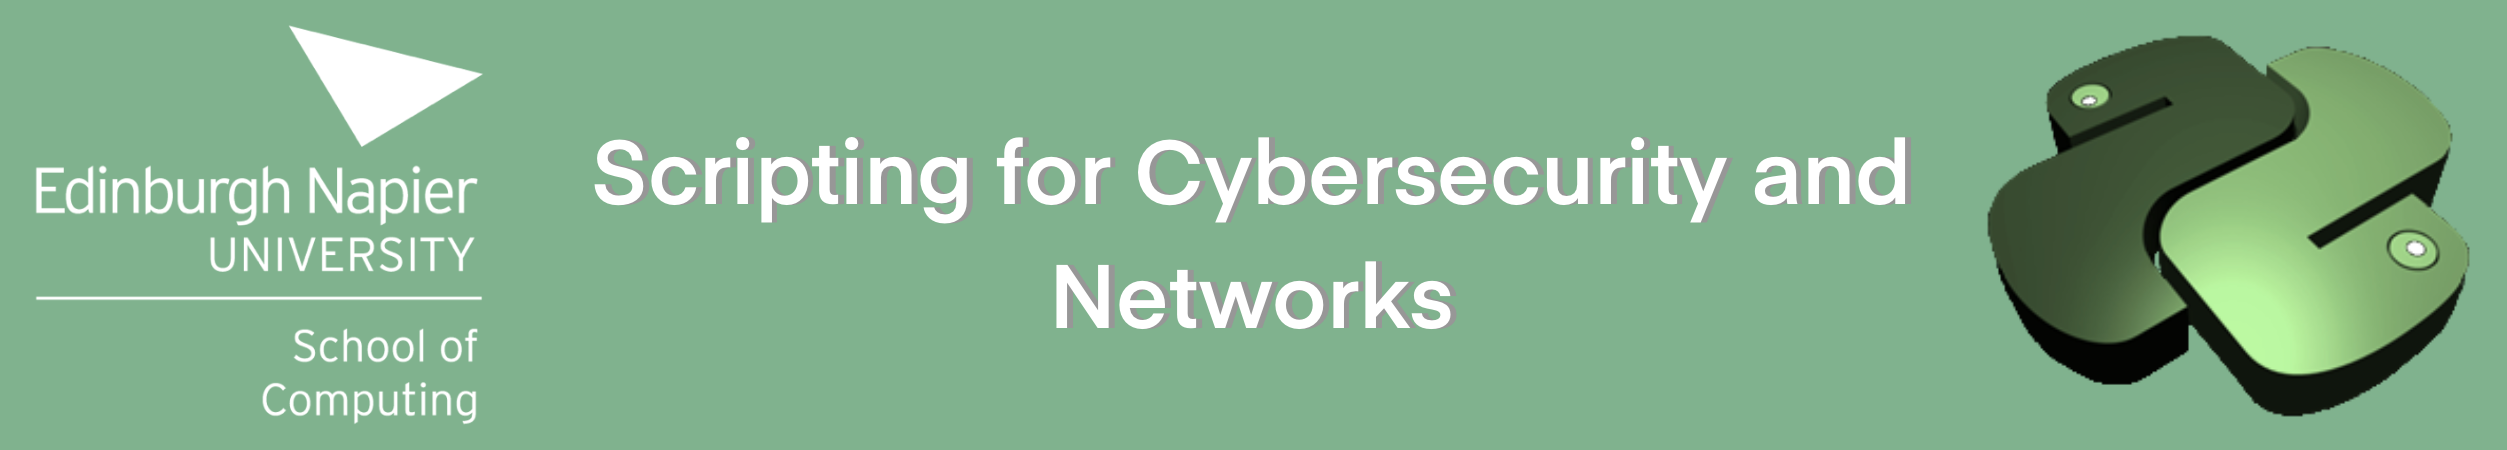

# Lab 04 Part 2: Computer networking with sockets

---

In lecture L4.3, we introduced sockets and discussed how client and server sockets interact.  Review the lecture slides on sockets. 

---


## 1. Simple Server using Sockets - Receiving data
---

The server (recipient) creates a socket then waits for a client to connect and send it some data. Some real-world examples of servers are ftp and telnet which process commands from a client and return the results.   
We'll create a simple server which receives data from the client, prints it to the screen and returns a confirmation to the client e.g. ‘Got that thanks!’.

**Open server.py and review the code**

---

Q1.1: What does ‘localhost’ represent? Why do we use that for the initial test?

---

Q1.2: What ip address does localhost resolve to?

---

Q1.3: When creating the socket object, what do the following terms mean?    

---

The following webpages are helpful for this question:
- https://whatismyipaddress.com/localhost
- https://pymotw.com/2/socket/addressing.html

Go through the script and use the lecture slides to help you understand how the script works, and remind yourself of all the steps required to create the listening socket.


**Starting your server**

Open a new terminal by going to     
**File >  New >  Terminal**
A new tab called Terminal 1 will appear

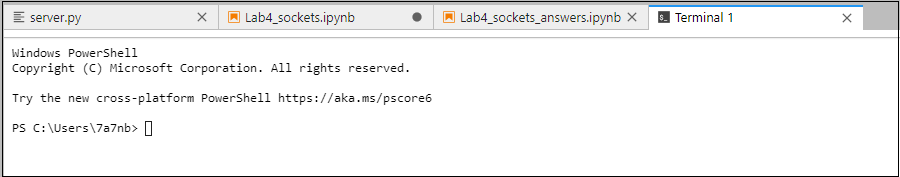

This will open in your default path, therefore you need to change the directory : cd \<path_to_Lab04\>    
Then run the python file **server.py**


You may get a firewall security alert pop up:

&emsp;&emsp;&emsp;&emsp;&emsp;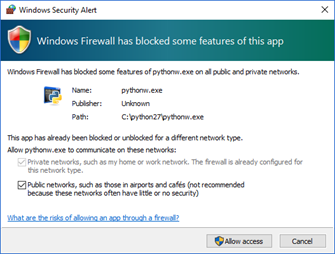



You should allow access in this case.
The script should run and indicate where the socket is listening. It will then wait.    
The output should look like….… 

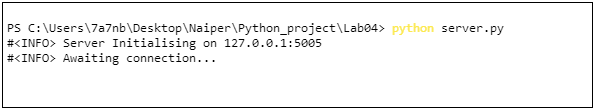



---

Q1.4: What is the ip address and port that the server is listening on? 

---

In another terminal, run as admin 'netstat -ano | findstr 5005' to find details of your server process:

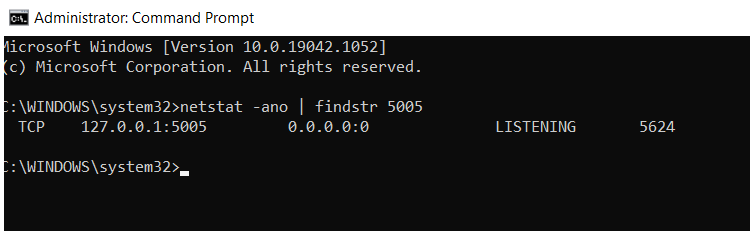

In the example above, my server's state and process ID are LISTENING and 5624 respectively.  
Q1.5: What is the State and process ID of your server? 

Note: If you need to stop the server running, go to Kernel and choose the "Restart Kernel and clear all outputs" option.

---

## 2. Connecting to the server
---

We are going to use Telnet to connect to the server giving the IP and port number of the server

### Running telnet for the first time (Windows 10)


Type in to the Windows search bar Telnet - option to "Turn windows features on or off" should appear

Click on Telnet client and allow to run

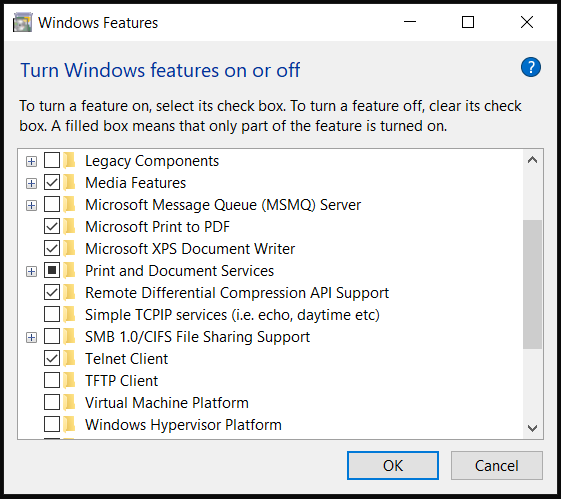

Once run type into search telnet again and run the Telnet command   
A command line Microsoft Telnet > will appear 



Make sure the server is running and confirmed awaiting connection

Type in to Telent prompt > o IP port  - the o is the command to connect, server ip, then port number

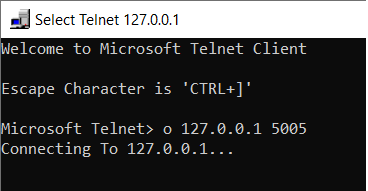

Client has connected to the server

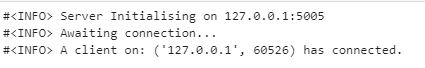

Try running Netstat while connected to the server

* **netstat -nao | findstr 5005**

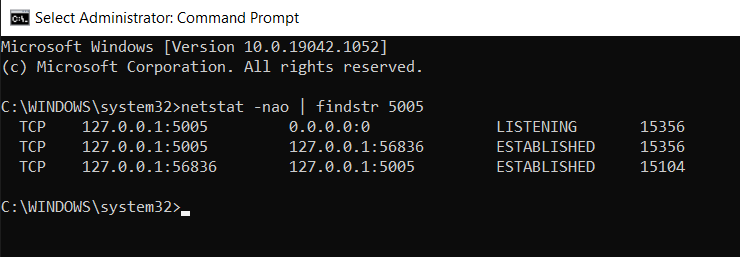


---

Q2.1: What is the State and process ID of your server? 

Q2.2: What is the state and process ID of the telnet client? What port is it running on?

Q2.3: Does the client port reported by the server match the client port for the process?

---
### Client sends some data to the server
---

In the Telnet client type some text. The Telnet and server window should look something like.....

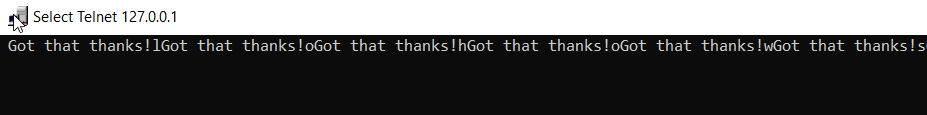

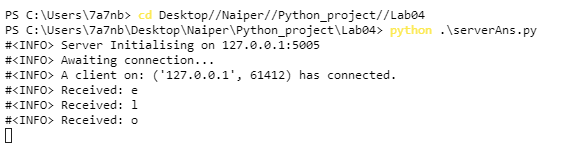



Telnet is sending each letter typed as an individual message; the server confirms each one.

---
### Client terminates
---

Kill the telnet client using the ‘taskkill’ command.  The PID is the process id of the client found previously, using netstat.     
Note: take care to kill the client process and not the server. 

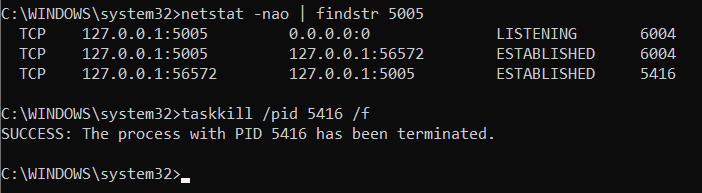

The terminal page output will look similar to this...

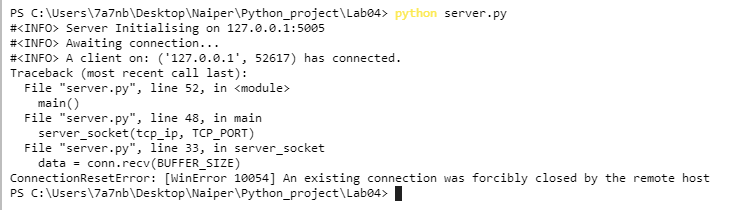


---
### Error handling when the client closes the connection
---

Add ‘try’ and ‘except’ statements around the ‘receive’ / ‘sendall’ block to trap the socket shutdown and exit cleanly, printing an informational message, similar to the one below.

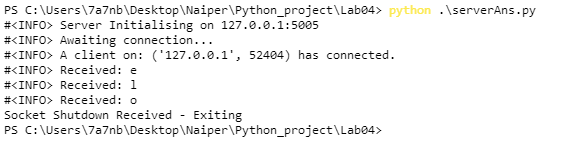

---

Q2.4: Explain, in your own words, how the script works. (Hint: check the steps for creating a server socket from the lecture and match each of these steps to a line or block of the code)

---

## 3. Client & Server using sockets
---

Now create a client script.  A starter script is provided     
Open **Client.py**

Test the starting script by running it in a new terminal. It should run, but not do much yet!  Now complete the script.   
**Tip**: Use the server script and lecture slides for information and example code. 
Once you think you have the script completed, first Check the cell before syntax errors. If that works ok, you are ready to see if you can send a message!


---

Q3.1: In which order do we need to run the two scripts? Why?

---

You should be able to send a message from the client and see this has been received in the output from the server. The output will look similar to this…

Server started in terminal and listening for connection

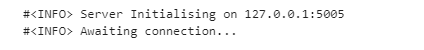

Client started, message entered, transmitted and confirmation received:

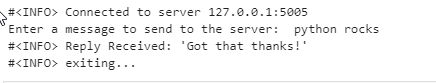

Server receives message and exits cleanly:

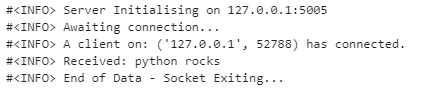

---

Q3.2: Why do we use the server's name or address in both scripts? Why don't we need to know the client's address? 

---
### Understanding the buffer size
---

To verify that you really understand the purpose of the BUFFER_SIZE variable and the loop in the server script, change the BUFFER_SIZE in server script above to 10 and test the scripts with the message…
* my message is longer than the buffer




---

Q3.3: What happens to the message received by the server ?

Q3.4: Why do we use a while loop and not a for loop? How exactly does this while loop work?

**Note**: Before continuing, change the buffer size back to 1024.

---
### Networked Client/Server
---

<span style='color:red'>This may not work in the lab due to security settings</span>

So far, both the client and server have been running on the local machine using '127.0.0.1' as the ip address. A more flexible solution would be to have the client and server run on different machines communicating over a network. To achieve this, follow these steps…  

**Step 1:** Amend your server to identify the hostname using socket.gethostname() and use that result to obtain the ip address. i.e.
~~~python
tcp_ip = socket.gethostbyname(socket.gethostname())
~~~
Run the server and examine the output

---

Q3.3: What ip address is your server running on? 

---

Q3.4: What is your machines IP address (Hint: run ipconfig from windows command line)

---

**Step 2:**  Amend the client script to accept the ip address and port as command-line arguments e.g 

Run the client supplying the ip address and port of the server as parameters. 
Once this works, pair up with a friend and try sending a message from one lab machine to another – one of you will be the server, the other the client. 


---